<a href="https://colab.research.google.com/github/ErisonBarros/Fotogrametria01/blob/erison.barros/Est%C3%A9reo_Vis%C3%A3o_com_OpenCVipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install opencv-python opencv-contrib-python


In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Carregar as imagens estéreo
img_left = cv2.imread('/content/drive/MyDrive/Fotos Celular/Imagem do WhatsApp de 2025-05-12 à(s) 16.31.50_e39e2b4f.jpg', cv2.IMREAD_GRAYSCALE)
img_right = cv2.imread('/content/drive/MyDrive/Fotos Celular/Imagem do WhatsApp de 2025-05-12 à(s) 16.32.07_9ddb7a88.jpg', cv2.IMREAD_GRAYSCALE)

In [4]:
# Verificar se as imagens foram carregadas
if img_left is None or img_right is None:
    raise IOError("Imagens não encontradas. Certifique-se de que 'left.png' e 'right.png' existem.")


In [5]:
# Criar o objeto estéreo usando o algoritmo StereoBM
stereo = cv2.StereoBM_create(numDisparities=64, blockSize=15)

In [6]:
# Calcular a disparidade
disparity = stereo.compute(img_left, img_right)

In [7]:
# Normalizar para visualização
disparity_normalized = cv2.normalize(disparity, None, alpha=0, beta=255, norm_type=cv2.NORM_MINMAX)
disparity_normalized = np.uint8(disparity_normalized)

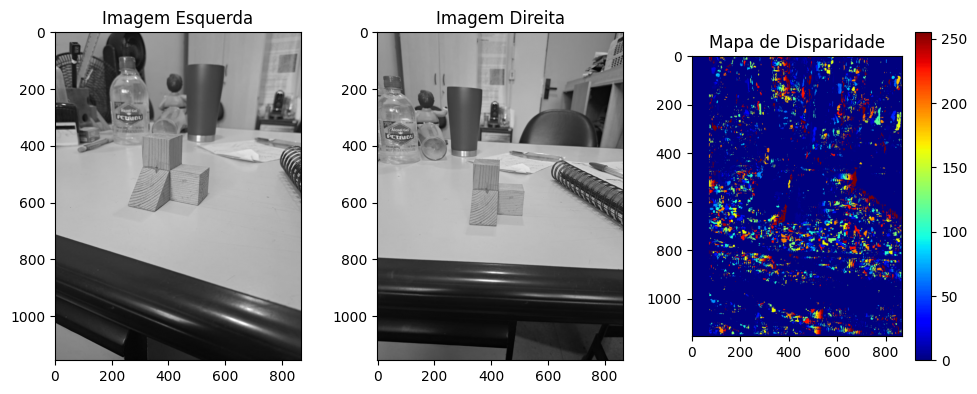

In [9]:
# Mostrar resultado
plt.figure(figsize=(10, 4))
plt.subplot(1, 3, 1)
plt.title("Imagem Esquerda")
plt.imshow(img_left, cmap='gray')

plt.subplot(1, 3, 2)
plt.title("Imagem Direita")
plt.imshow(img_right, cmap='gray')

plt.subplot(1, 3, 3)
plt.title("Mapa de Disparidade")
plt.imshow(disparity_normalized, cmap='jet')
plt.colorbar()
plt.tight_layout()
plt.show()